# Plots for Jacobian relations (velocity, force, etc.)

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import re

## Velocity

In [8]:
def plot_velocity(filename, start_line, end_line):
    columns = {}
    line_cnt = 0
    with open(filename, "r") as f:
        for i, line in enumerate(f):
            if start_line is not None and i < start_line:
                continue
            if end_line is not None and i > end_line:
                break

            pairs = re.findall(r"(v\d+):([-0-9.eE]+)", line)
            line_cnt+=1
            for key, value in pairs:
                if key not in columns:
                    columns[key] = []
                columns[key].append(float(value))

    plt.figure(figsize=(12, 8), dpi=300) 

    for key, values in columns.items():
        plt.plot(range(start_line, start_line + len(values)), values, label=key)

    plt.xlabel("Frame")
    plt.ylabel("Velocity")
    plt.title(f"Velocity Simulation Plot (v{start_line}–v{line_cnt})")
    plt.legend()
    plt.grid(True)
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(15)) 
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15)) 
    plt.tight_layout()
    plt.show()

def plot_pos(filename, start_line, end_line):
    solid_columns = {}   # t0–t5
    dashed_columns = {}  # x, y, z, phi, theta, psi
    # dash_line_columns = {} # sint

    patterns = {
        "solid": re.compile(r"(t\d+):\s*([-0-9.eE]+)"),
        "xyz": re.compile(r"(x|y|z):\s*([-0-9.eE]+)"),
        "angles": re.compile(r"(phi|theta|psi):\s*([-0-9.eE]+)"),
        # "sint": re.compile(r"(sin\(t\)):\s*([-0-9.eE]+)")
    }

    with open(filename, "r") as f:
        for i, line in enumerate(f):
            if start_line is not None and i < start_line:
                continue
            if end_line is not None and i > end_line:
                break

            for key, value in patterns["solid"].findall(line):
                if key not in solid_columns:
                    solid_columns[key] = []
                solid_columns[key].append(float(value))

            for key, value in patterns["xyz"].findall(line):
                if key not in dashed_columns:
                    dashed_columns[key] = []
                dashed_columns[key].append(float(value))

            for key, value in patterns["angles"].findall(line):
                if key not in dashed_columns:
                    dashed_columns[key] = []
                dashed_columns[key].append(float(value))

            # for key, value in patterns["sint"].findall(line):
            #     if key not in dash_line_columns:
            #         dash_line_columns[key] = []
            #     dash_line_columns[key].append(float(value))



    plt.figure(figsize=(14, 8), dpi=300)

    for key, values in solid_columns.items():
        plt.plot(range(start_line, start_line + len(values)), values, label=key, linestyle="-")

    for key, values in dashed_columns.items():
        plt.plot(range(start_line, start_line + len(values)), values, label=key, linestyle=":")

    # for key, values in dash_line_columns.items():
    #     plt.plot(range(start_line, start_line + len(values)), values, label=key, linestyle='-.')

        

    plt.xlabel("Frame")
    plt.ylabel("Value")
    plt.title("Position Simulation Plot (t0–t5 solid, x/y/z & phi/theta/psi dashed)")
    plt.legend()
    plt.grid(True)

    # plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    # plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%d'))
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(25)) 
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(25)) 

    plt.tight_layout()
    plt.show()

### Wrist Orientatio Change simulation

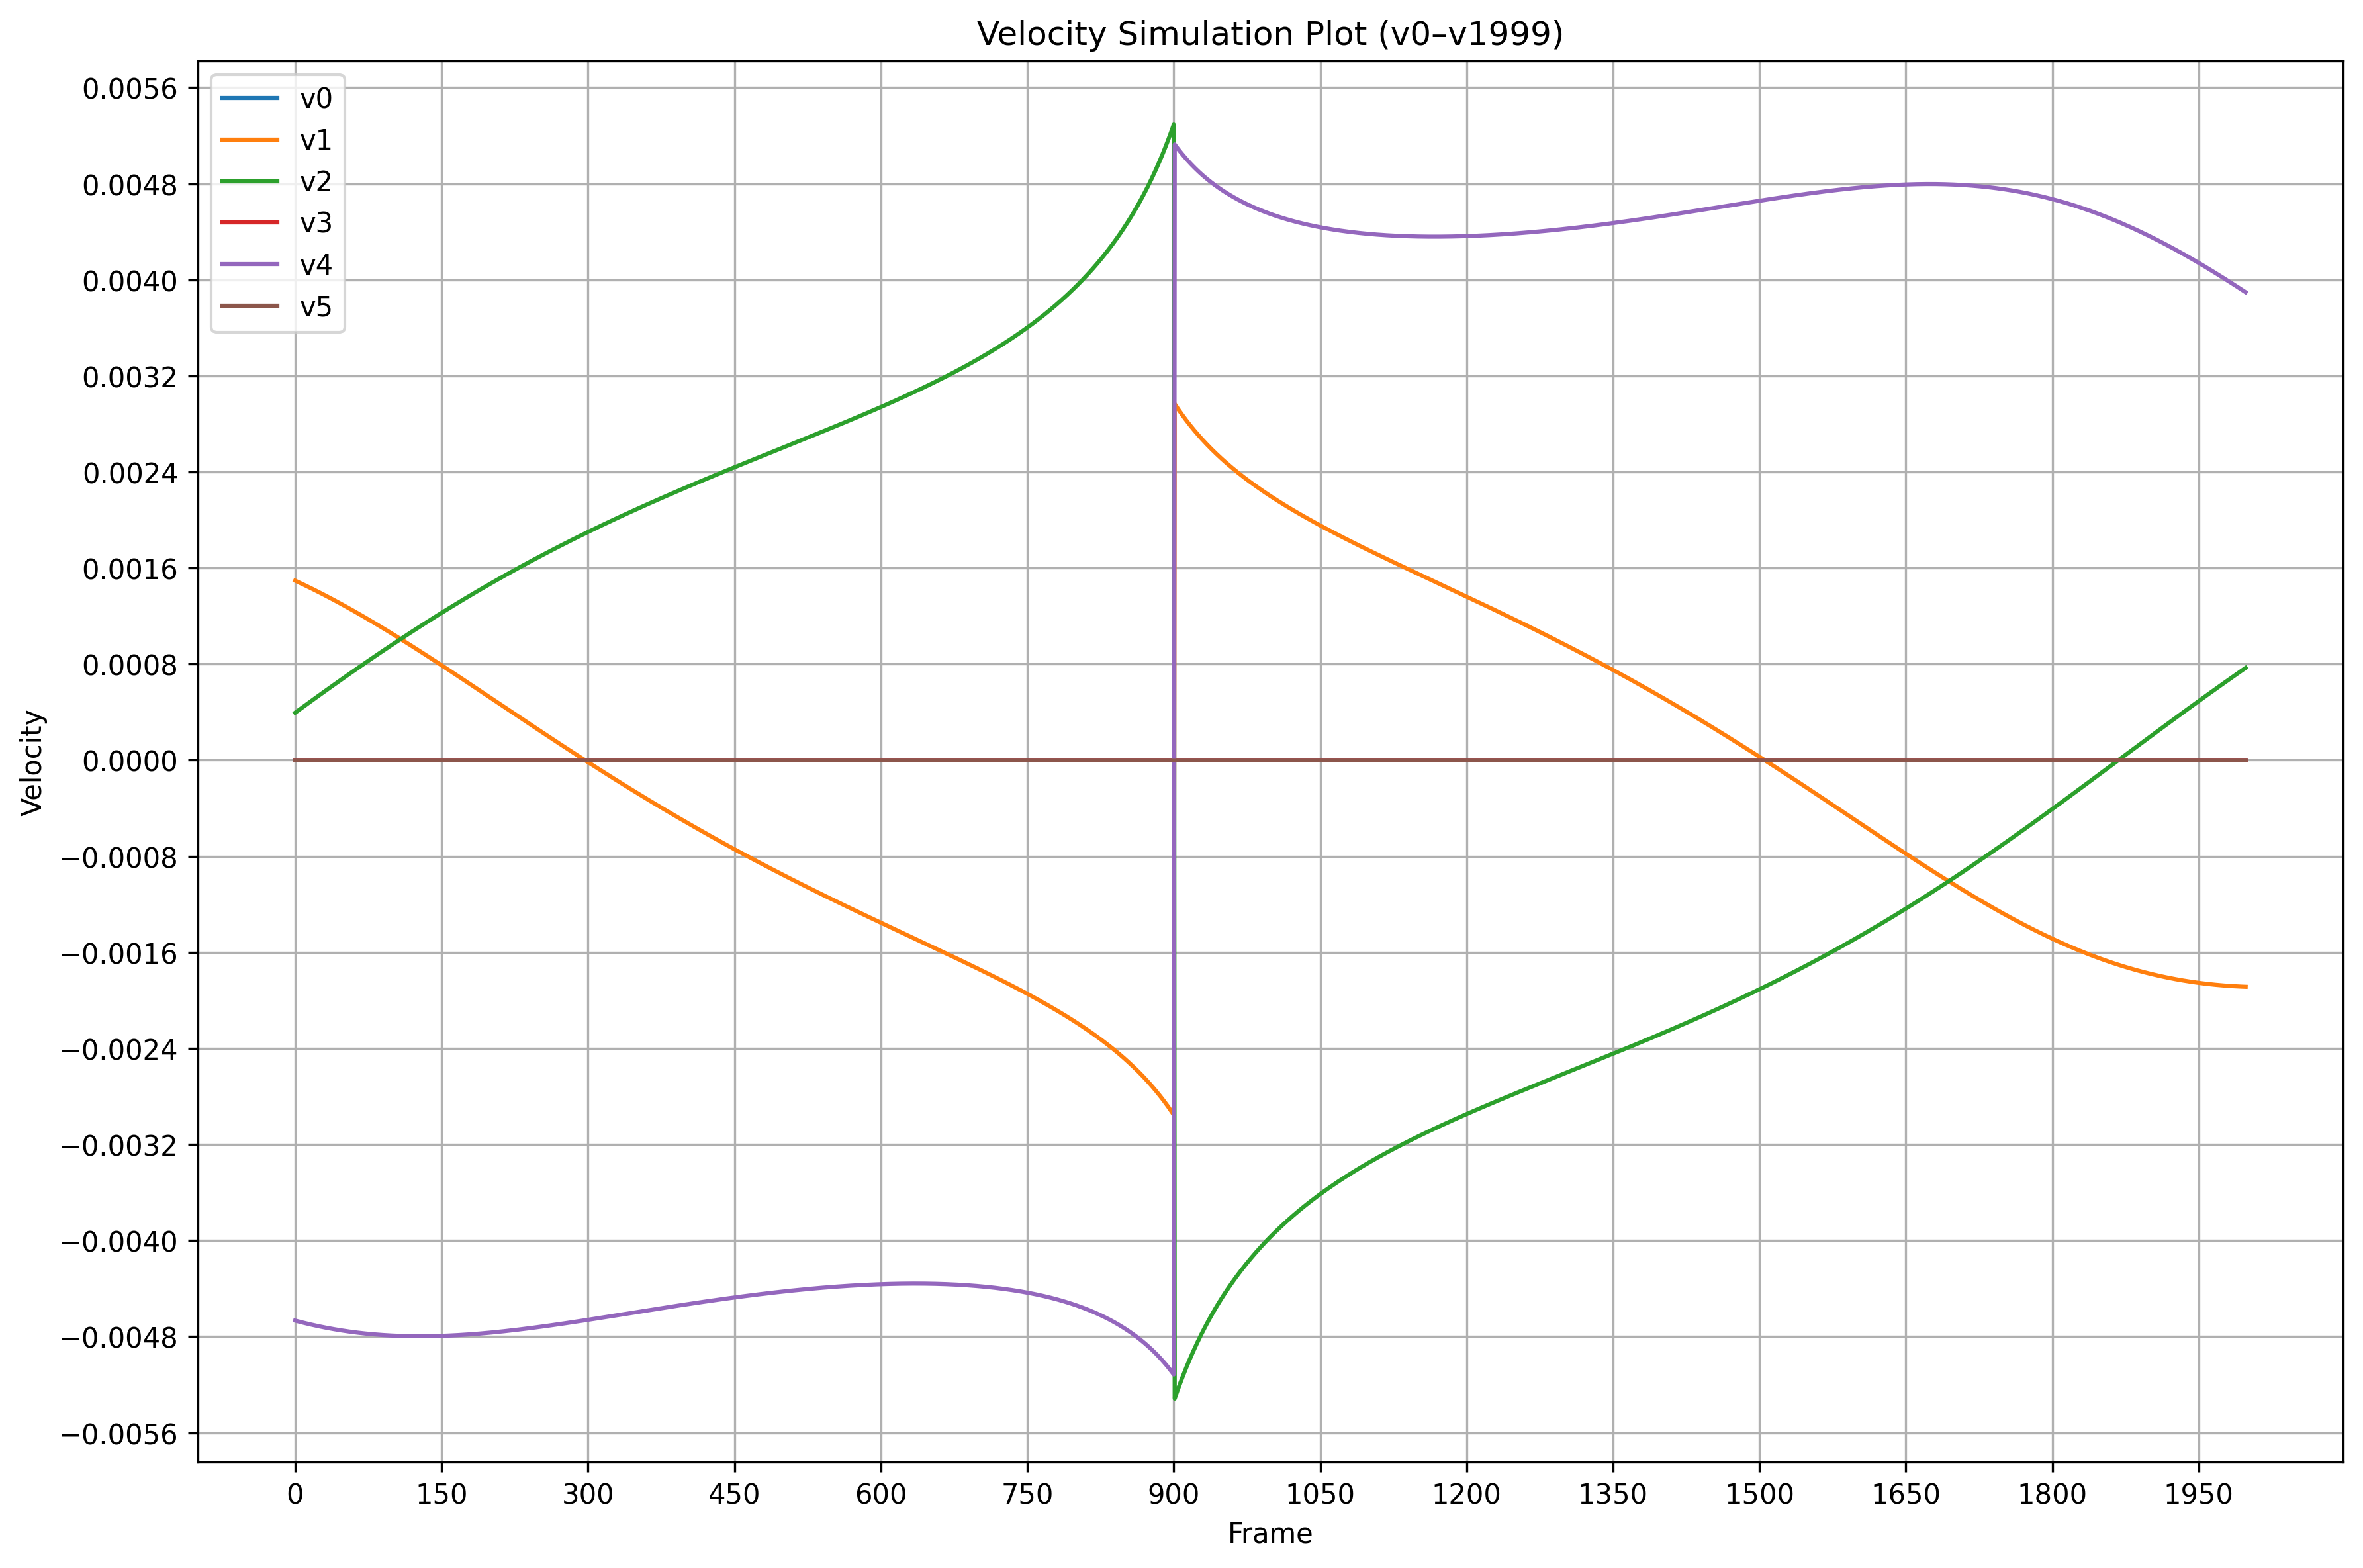

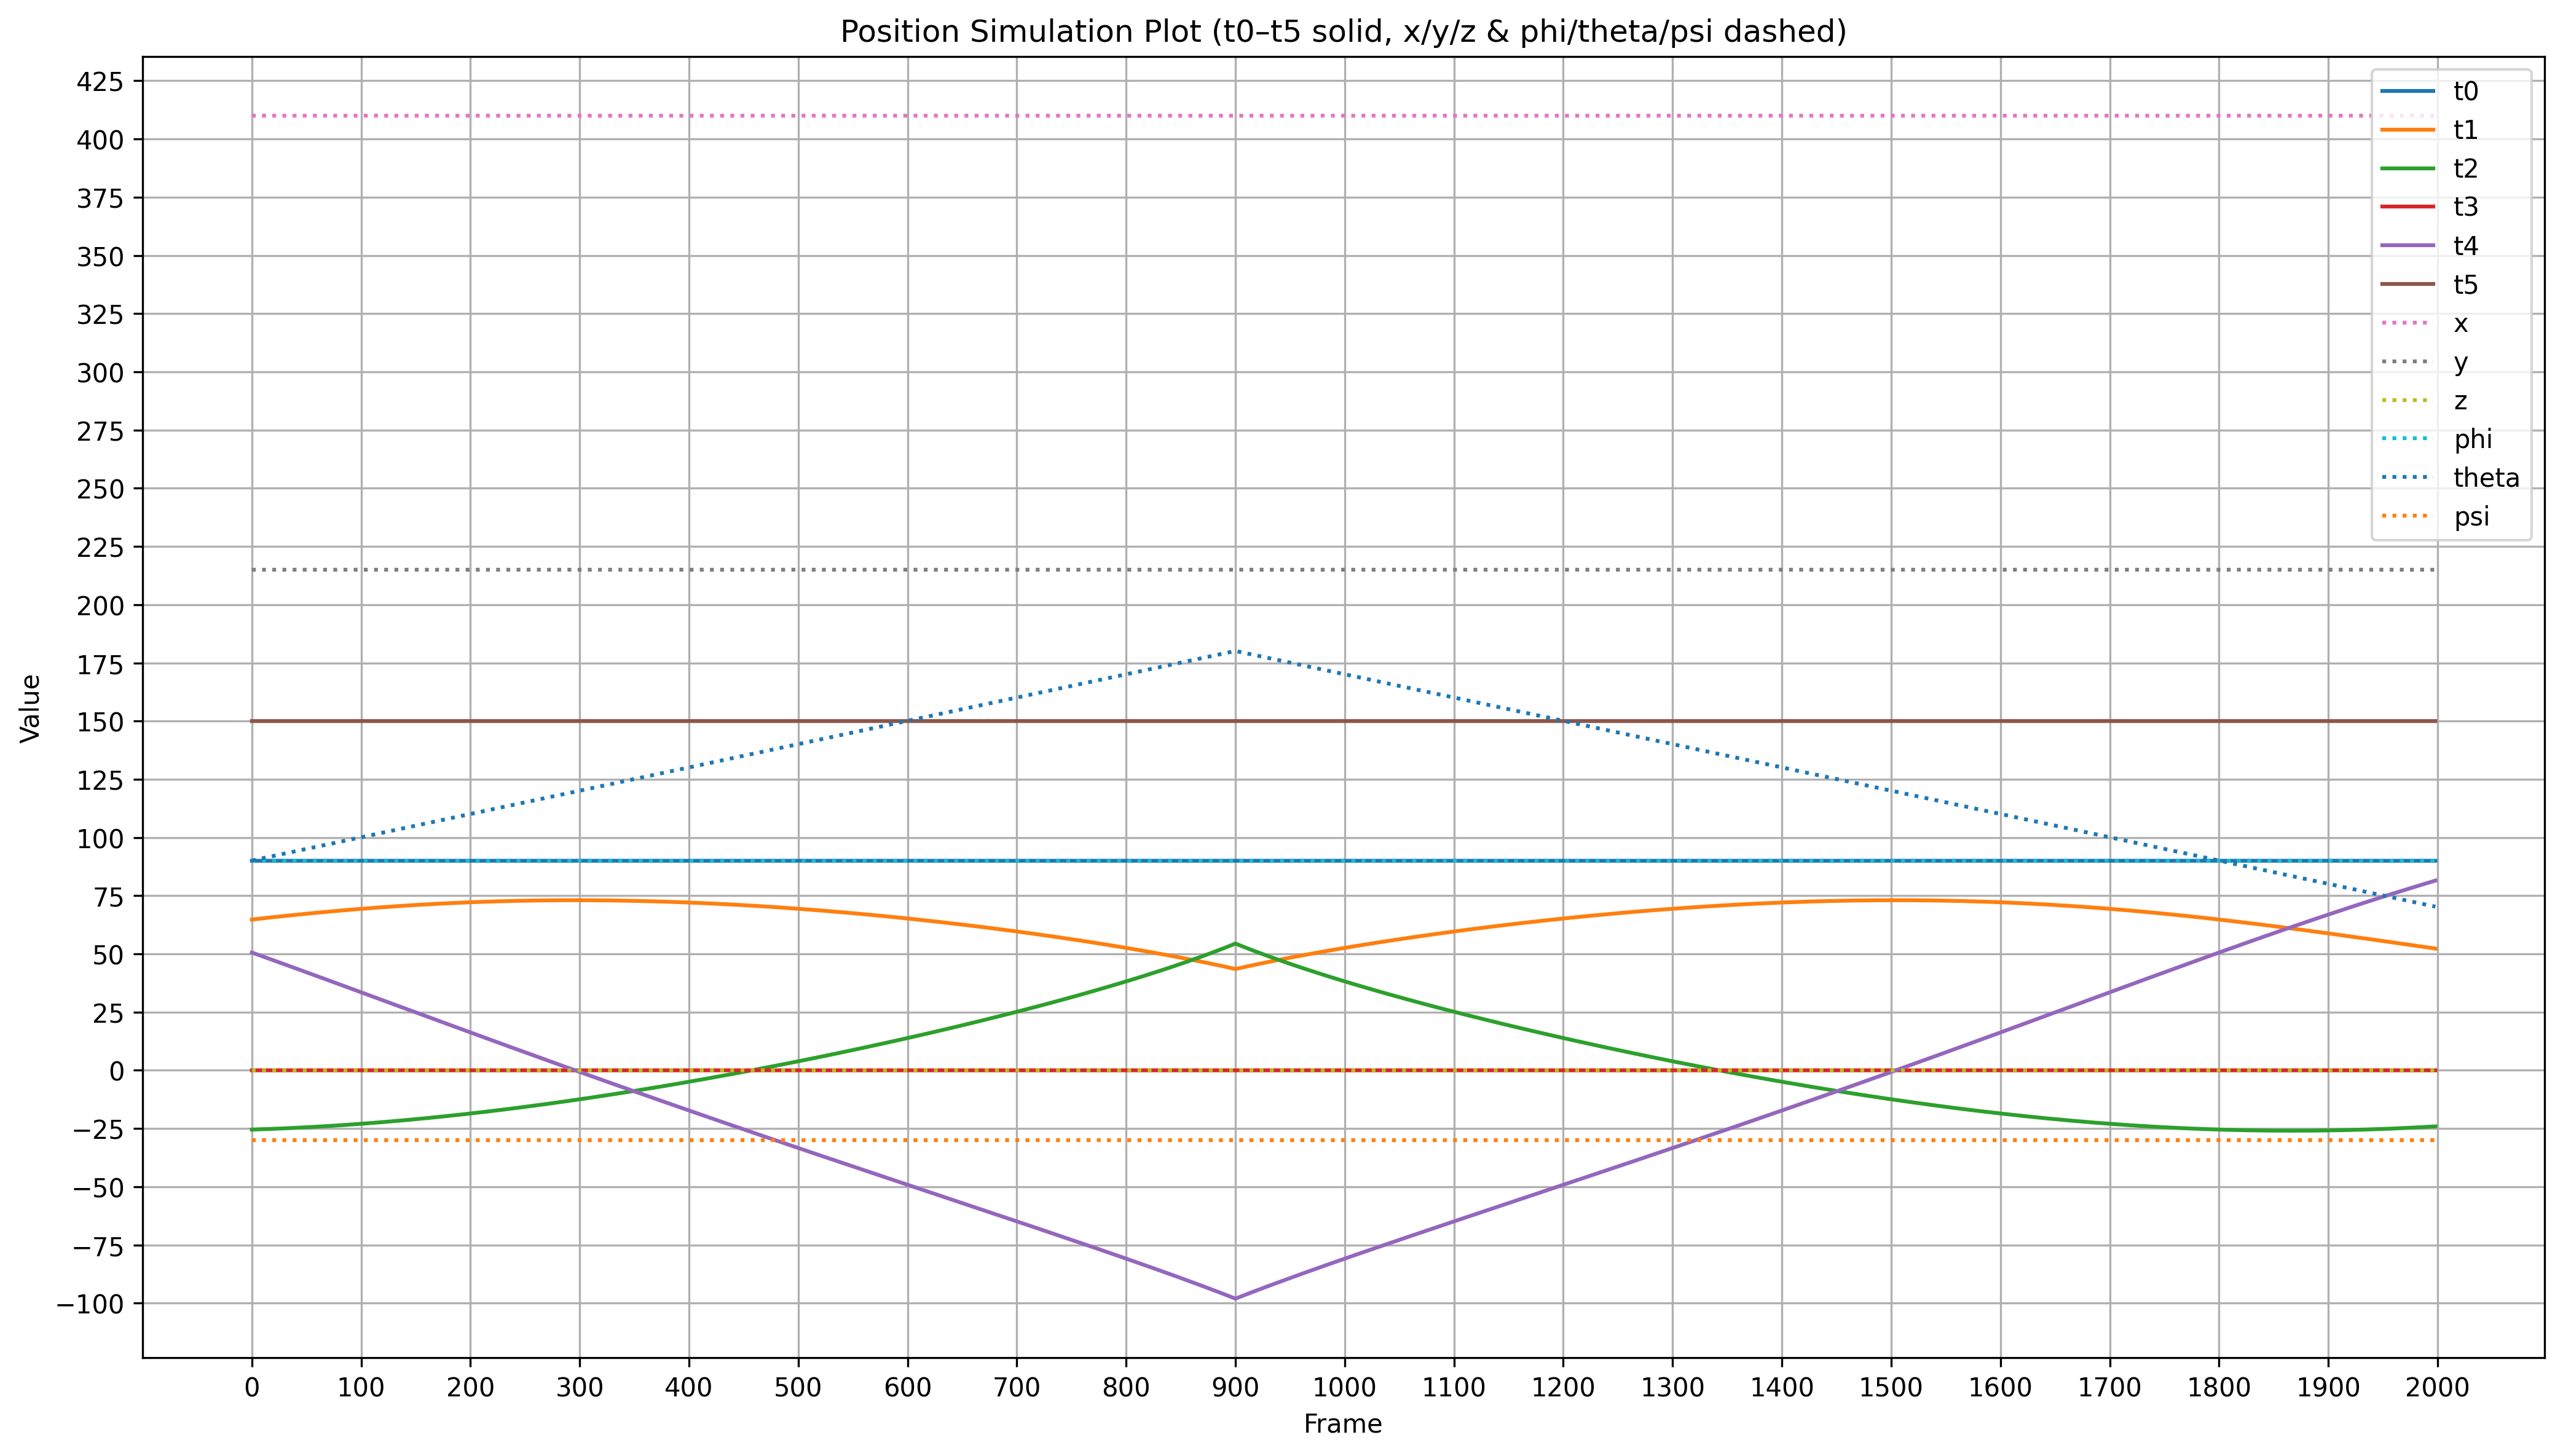

In [9]:
start_line = 0     
end_line = None


plot_velocity("sim_vel1.log", start_line, end_line)
plot_pos("sim_pos1.log", start_line, end_line)

### Simple Path Simulation (Postion Mode)

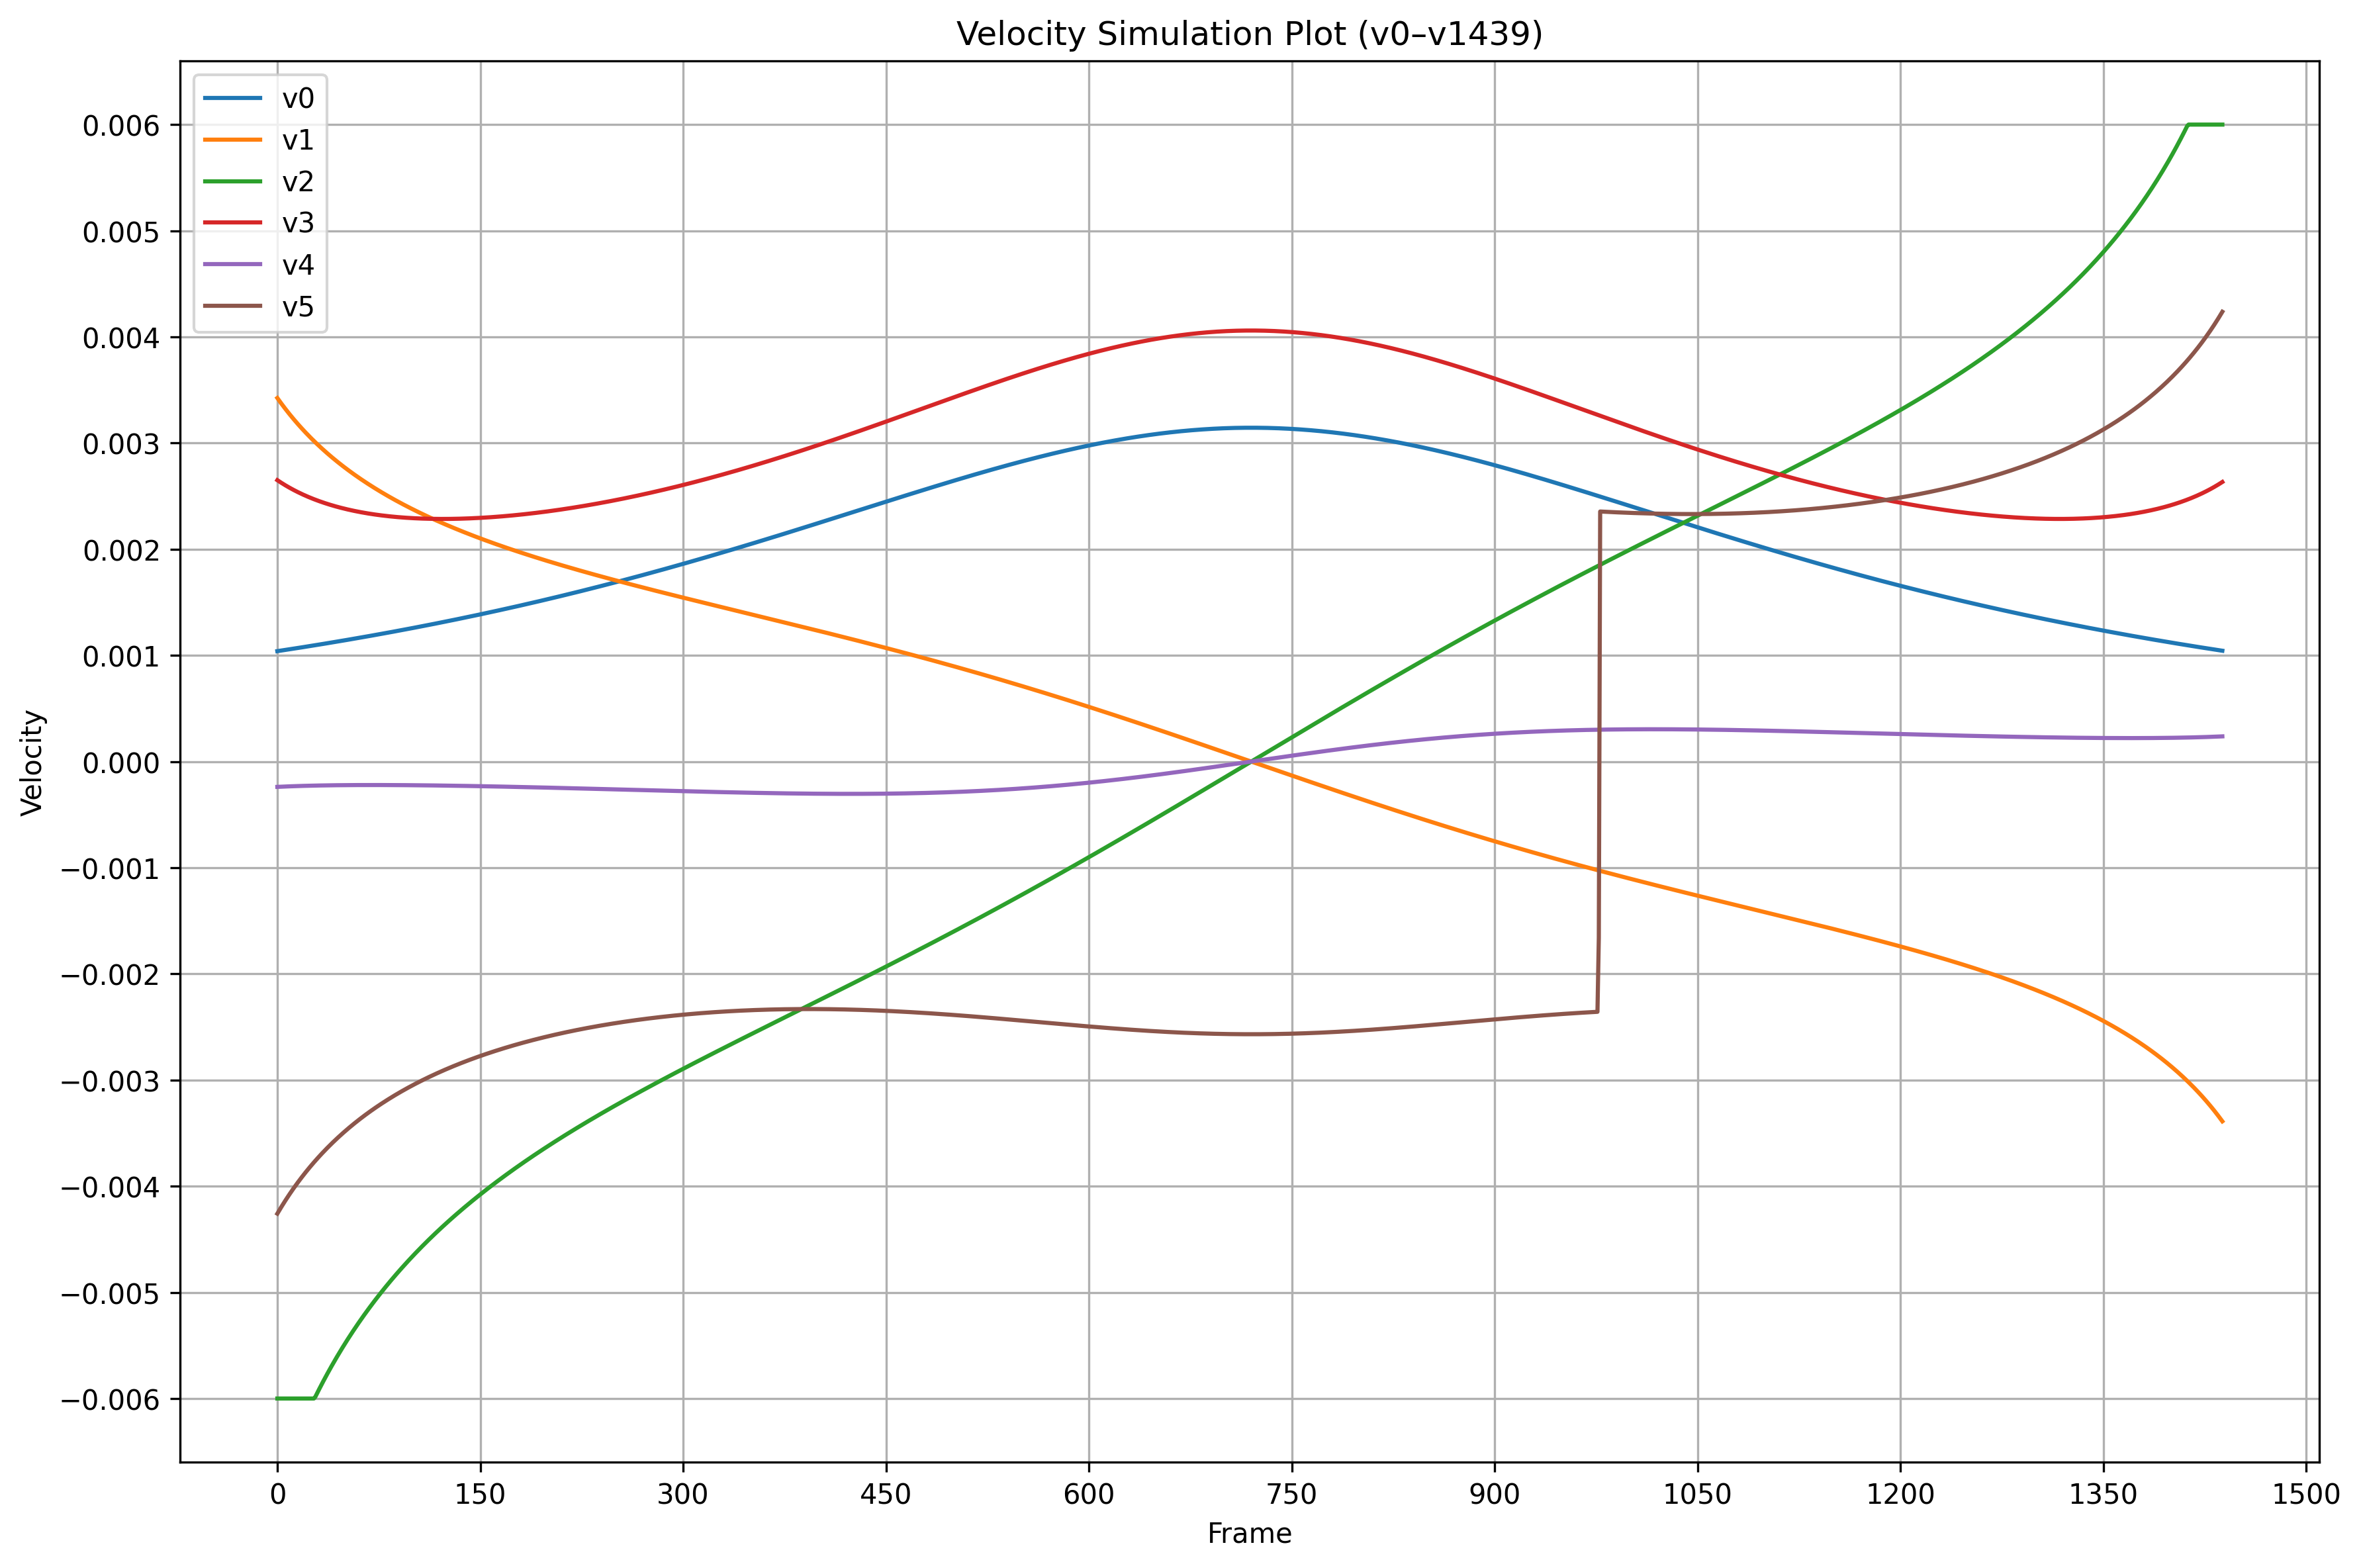

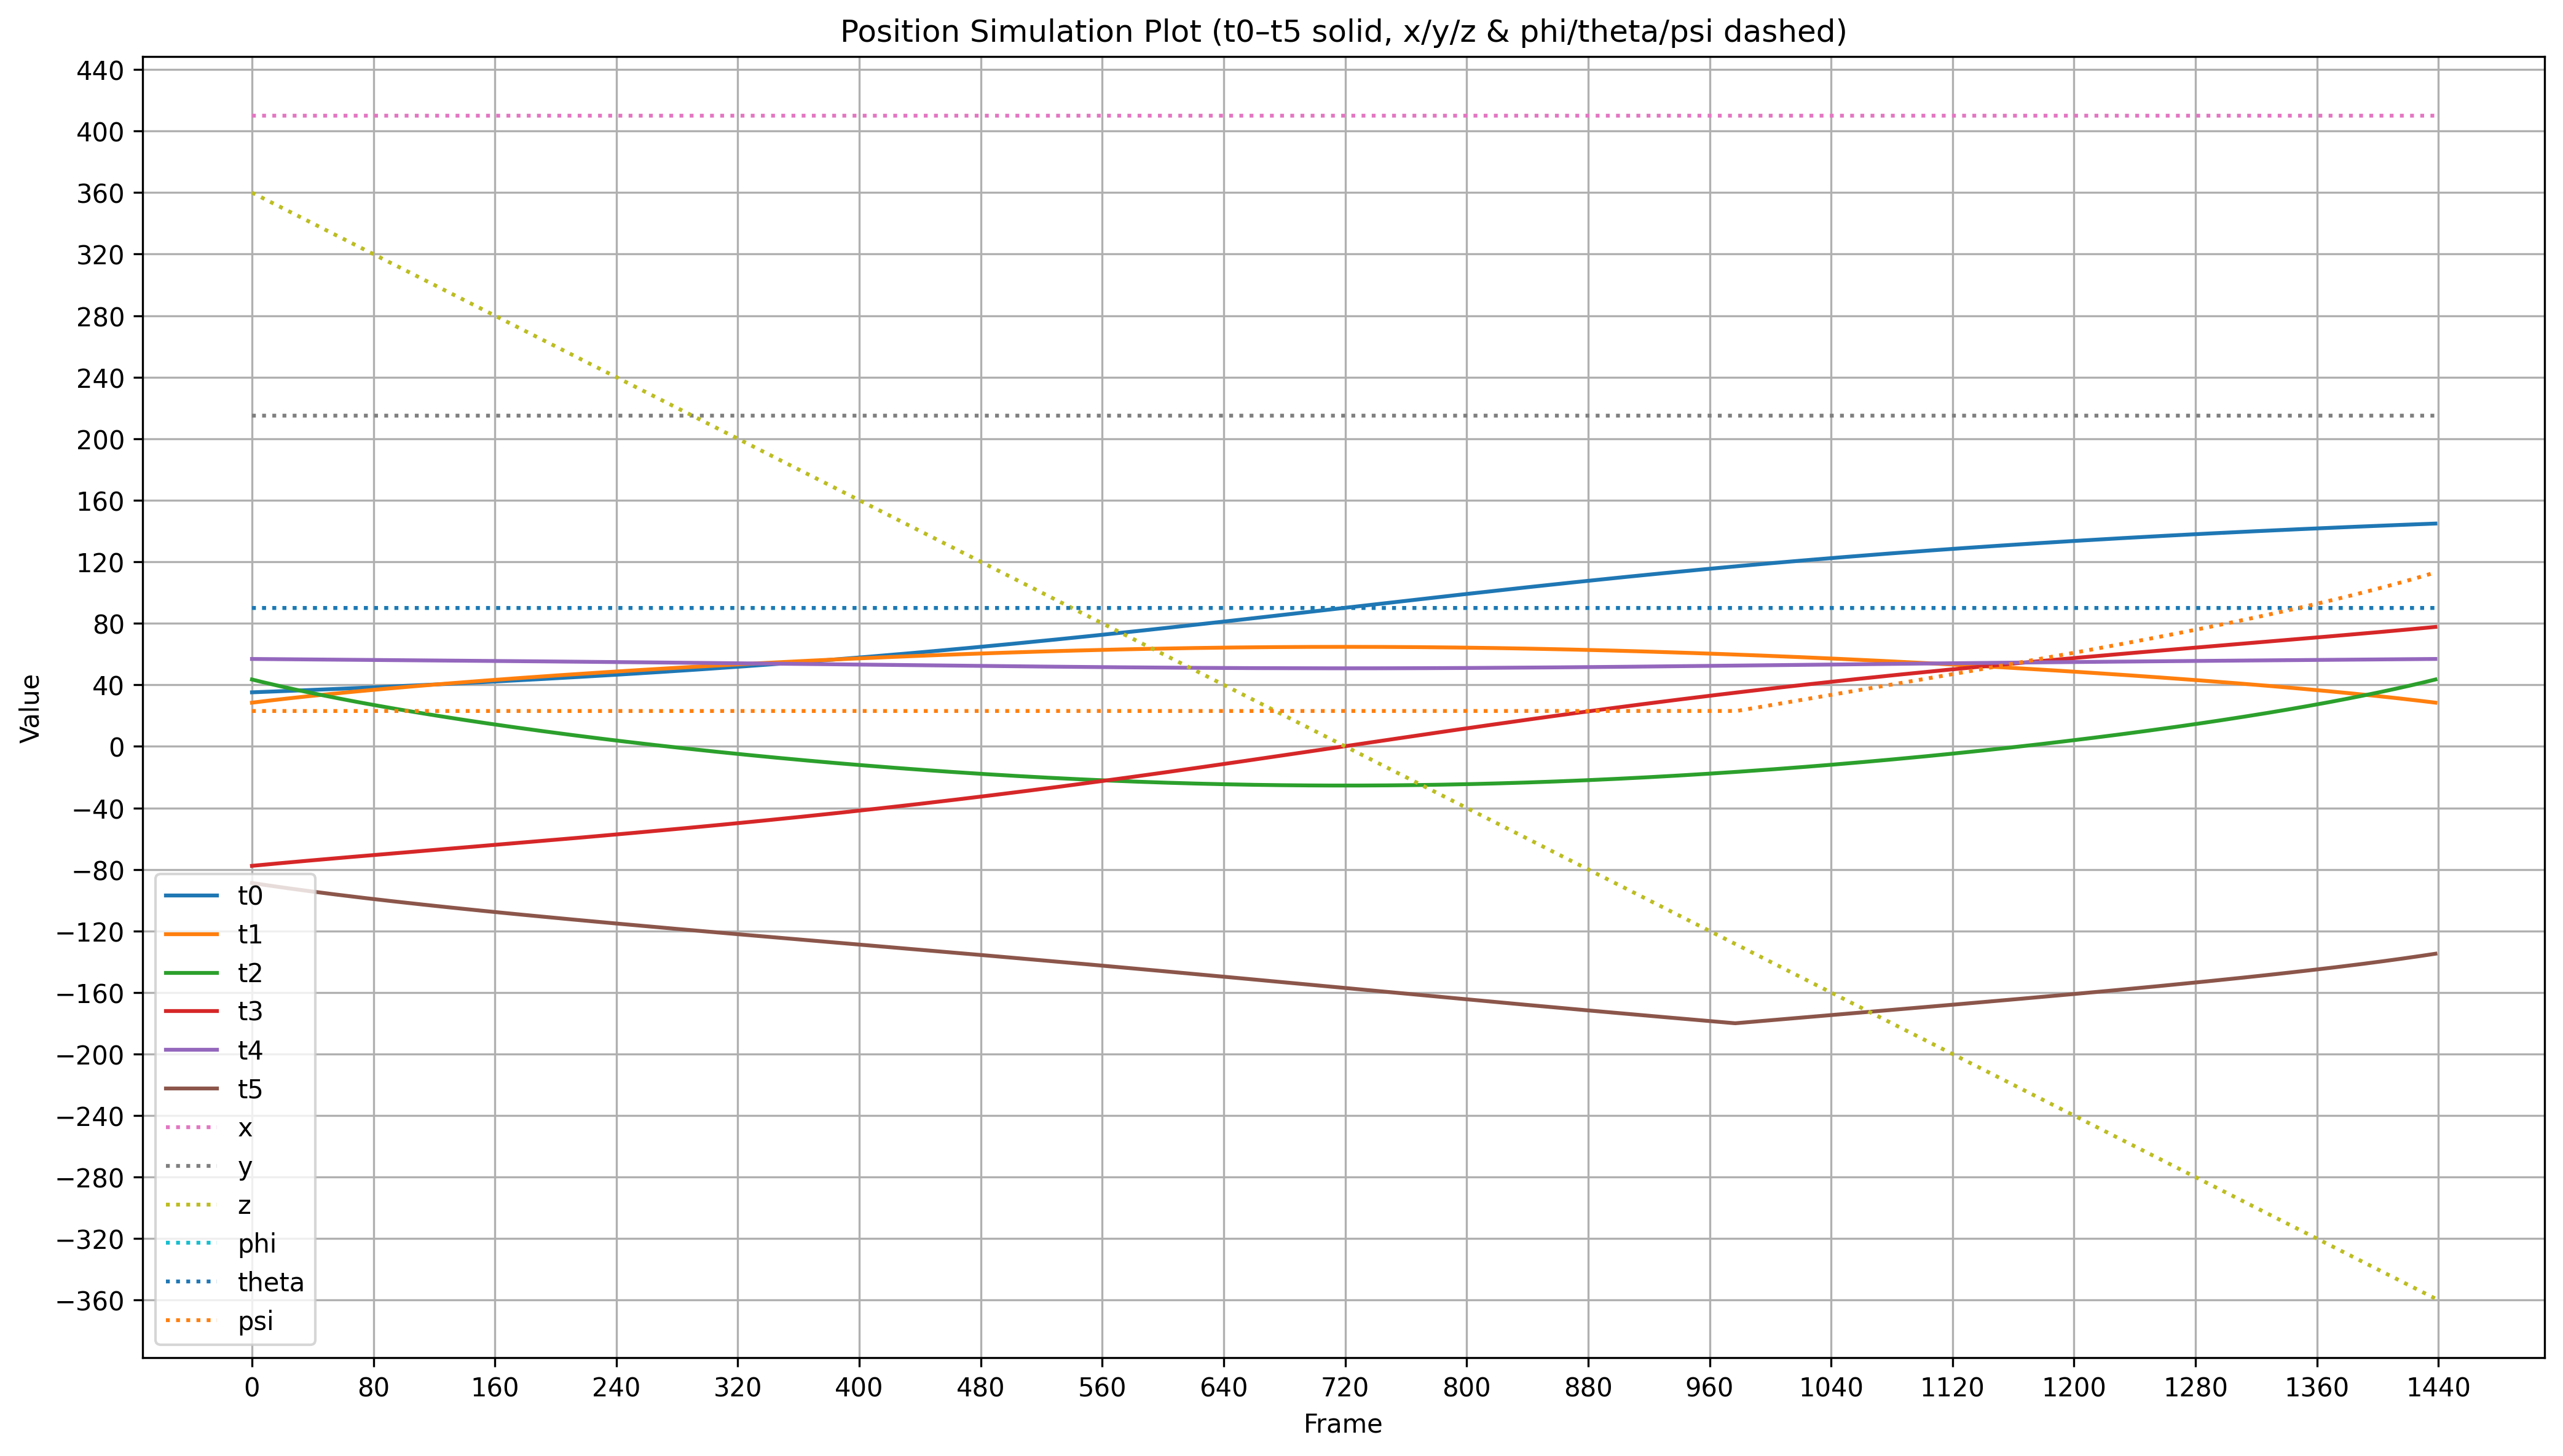

In [10]:
start_line = 0
end_line = None

plot_velocity("sim_vel2.log", start_line, end_line)
plot_pos("sim_pos2.log", start_line, end_line)

### Simple Path Simulation

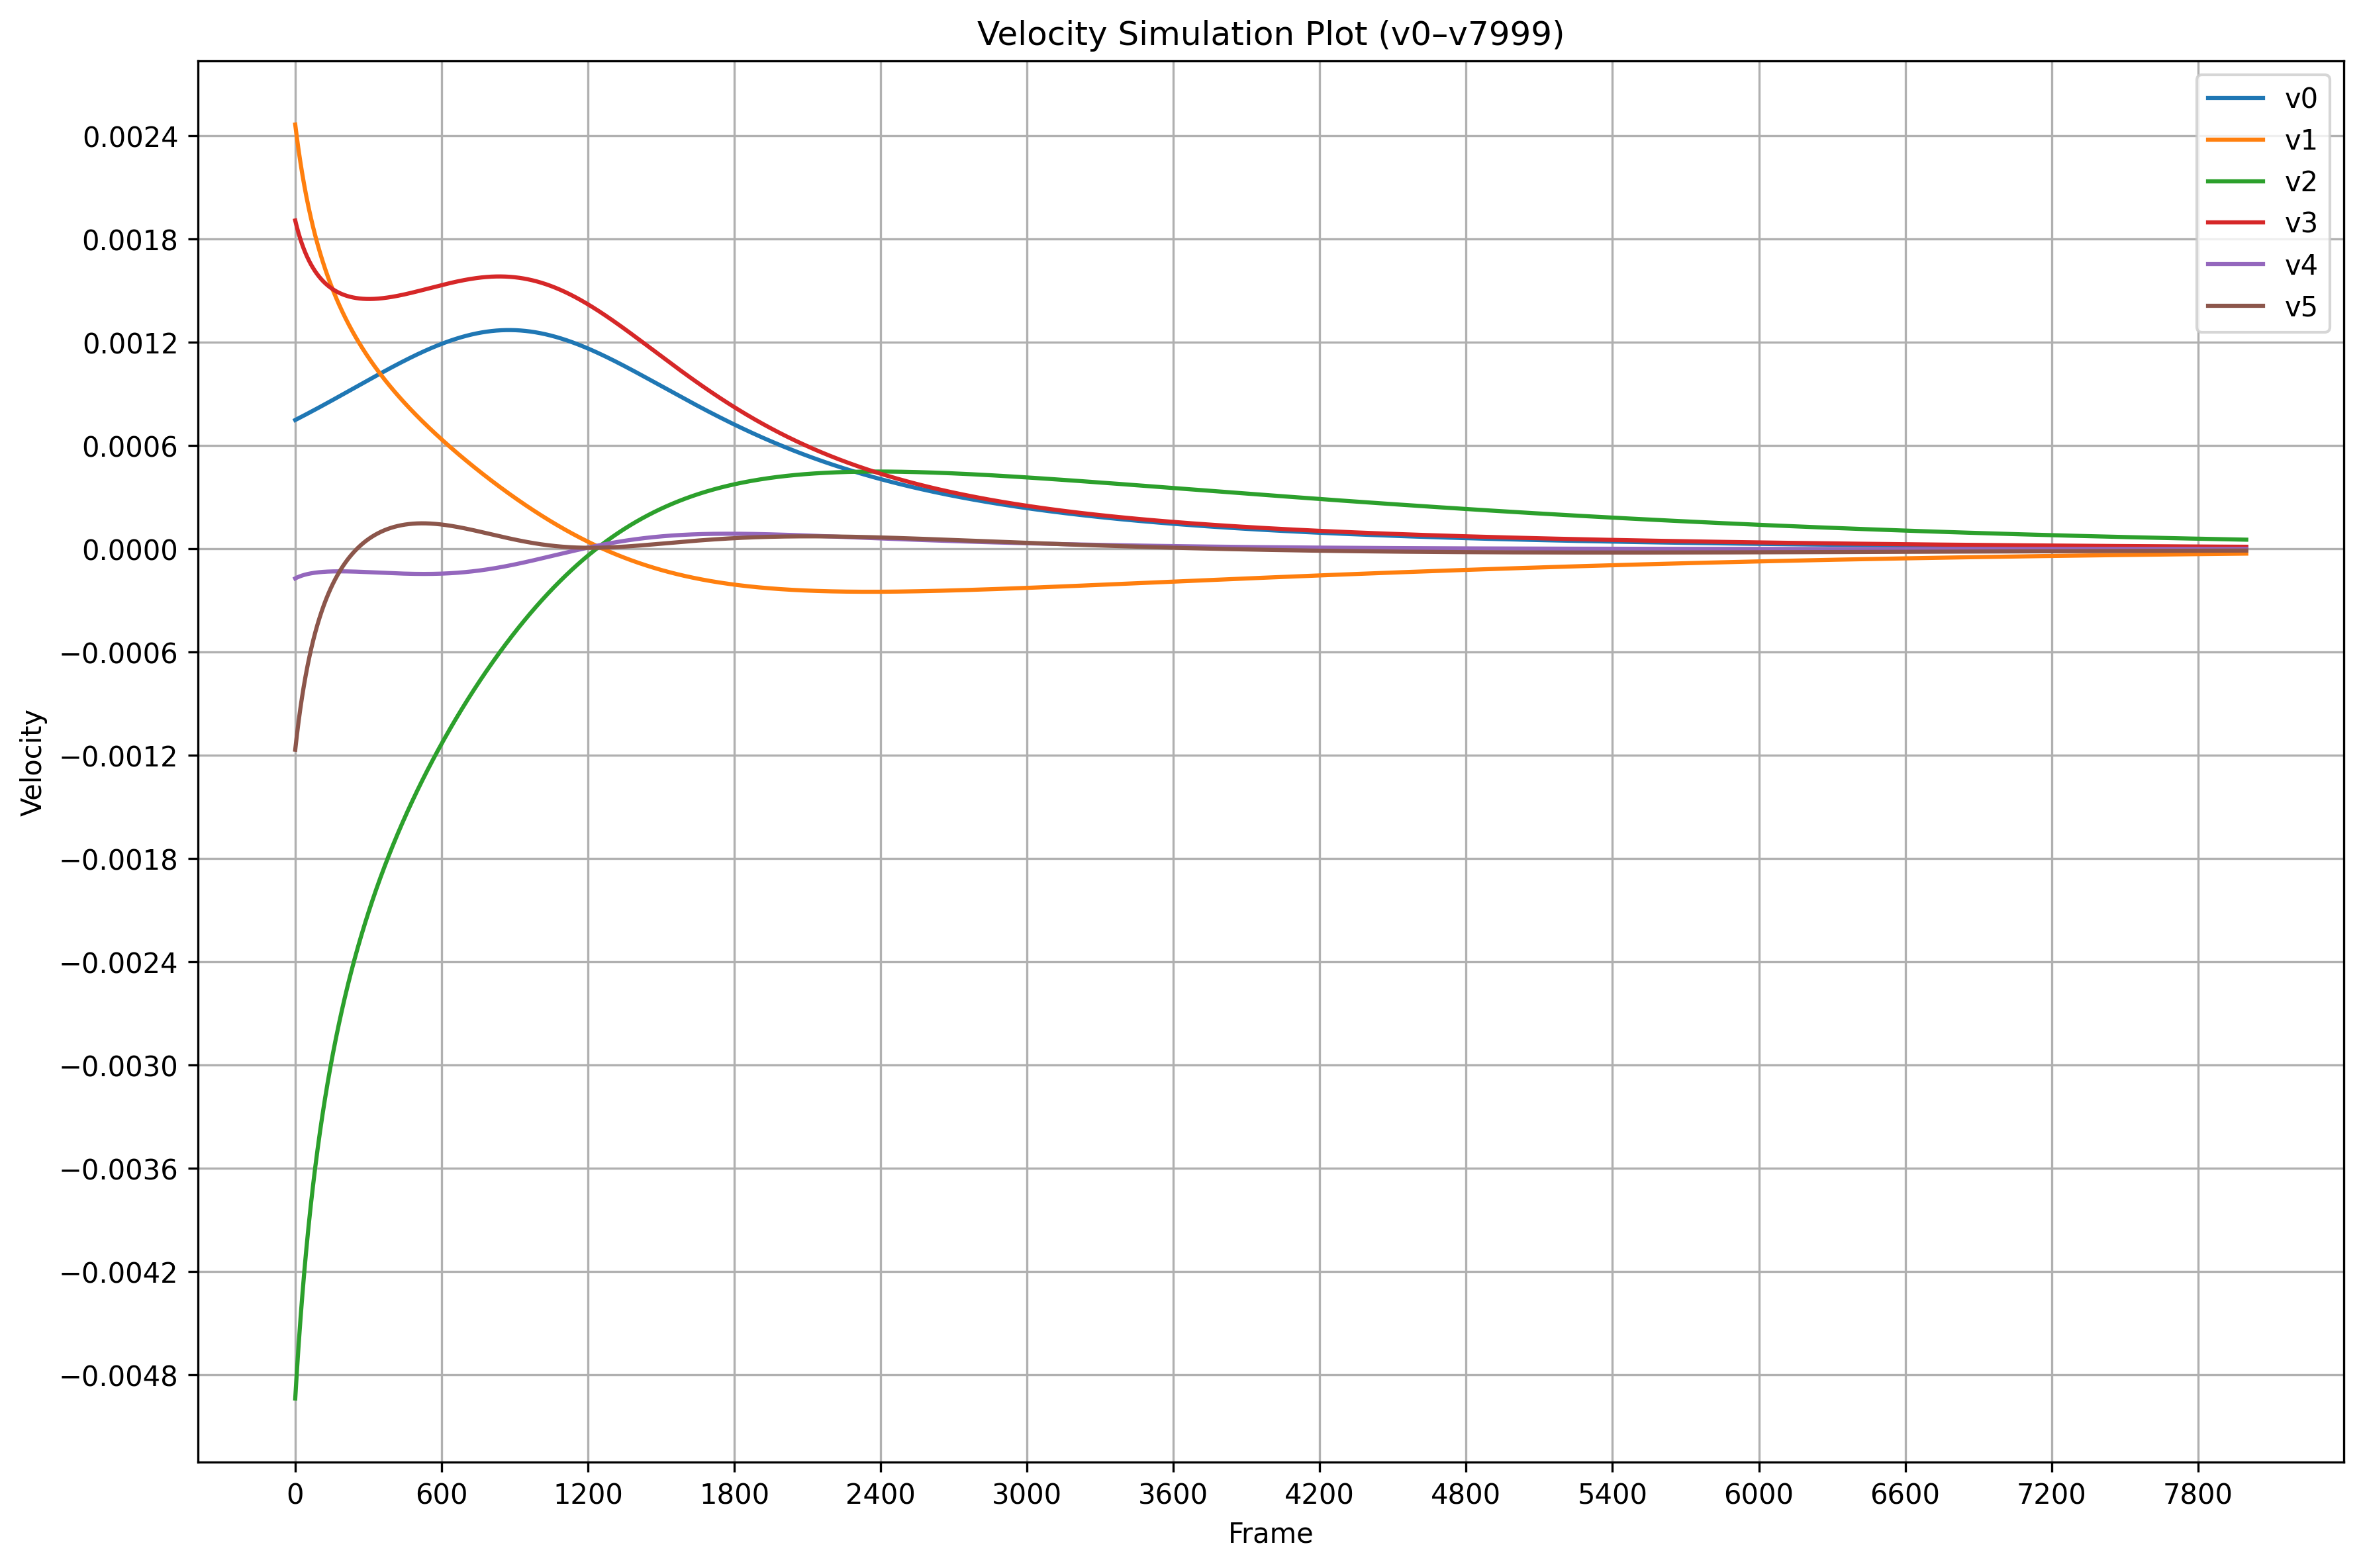

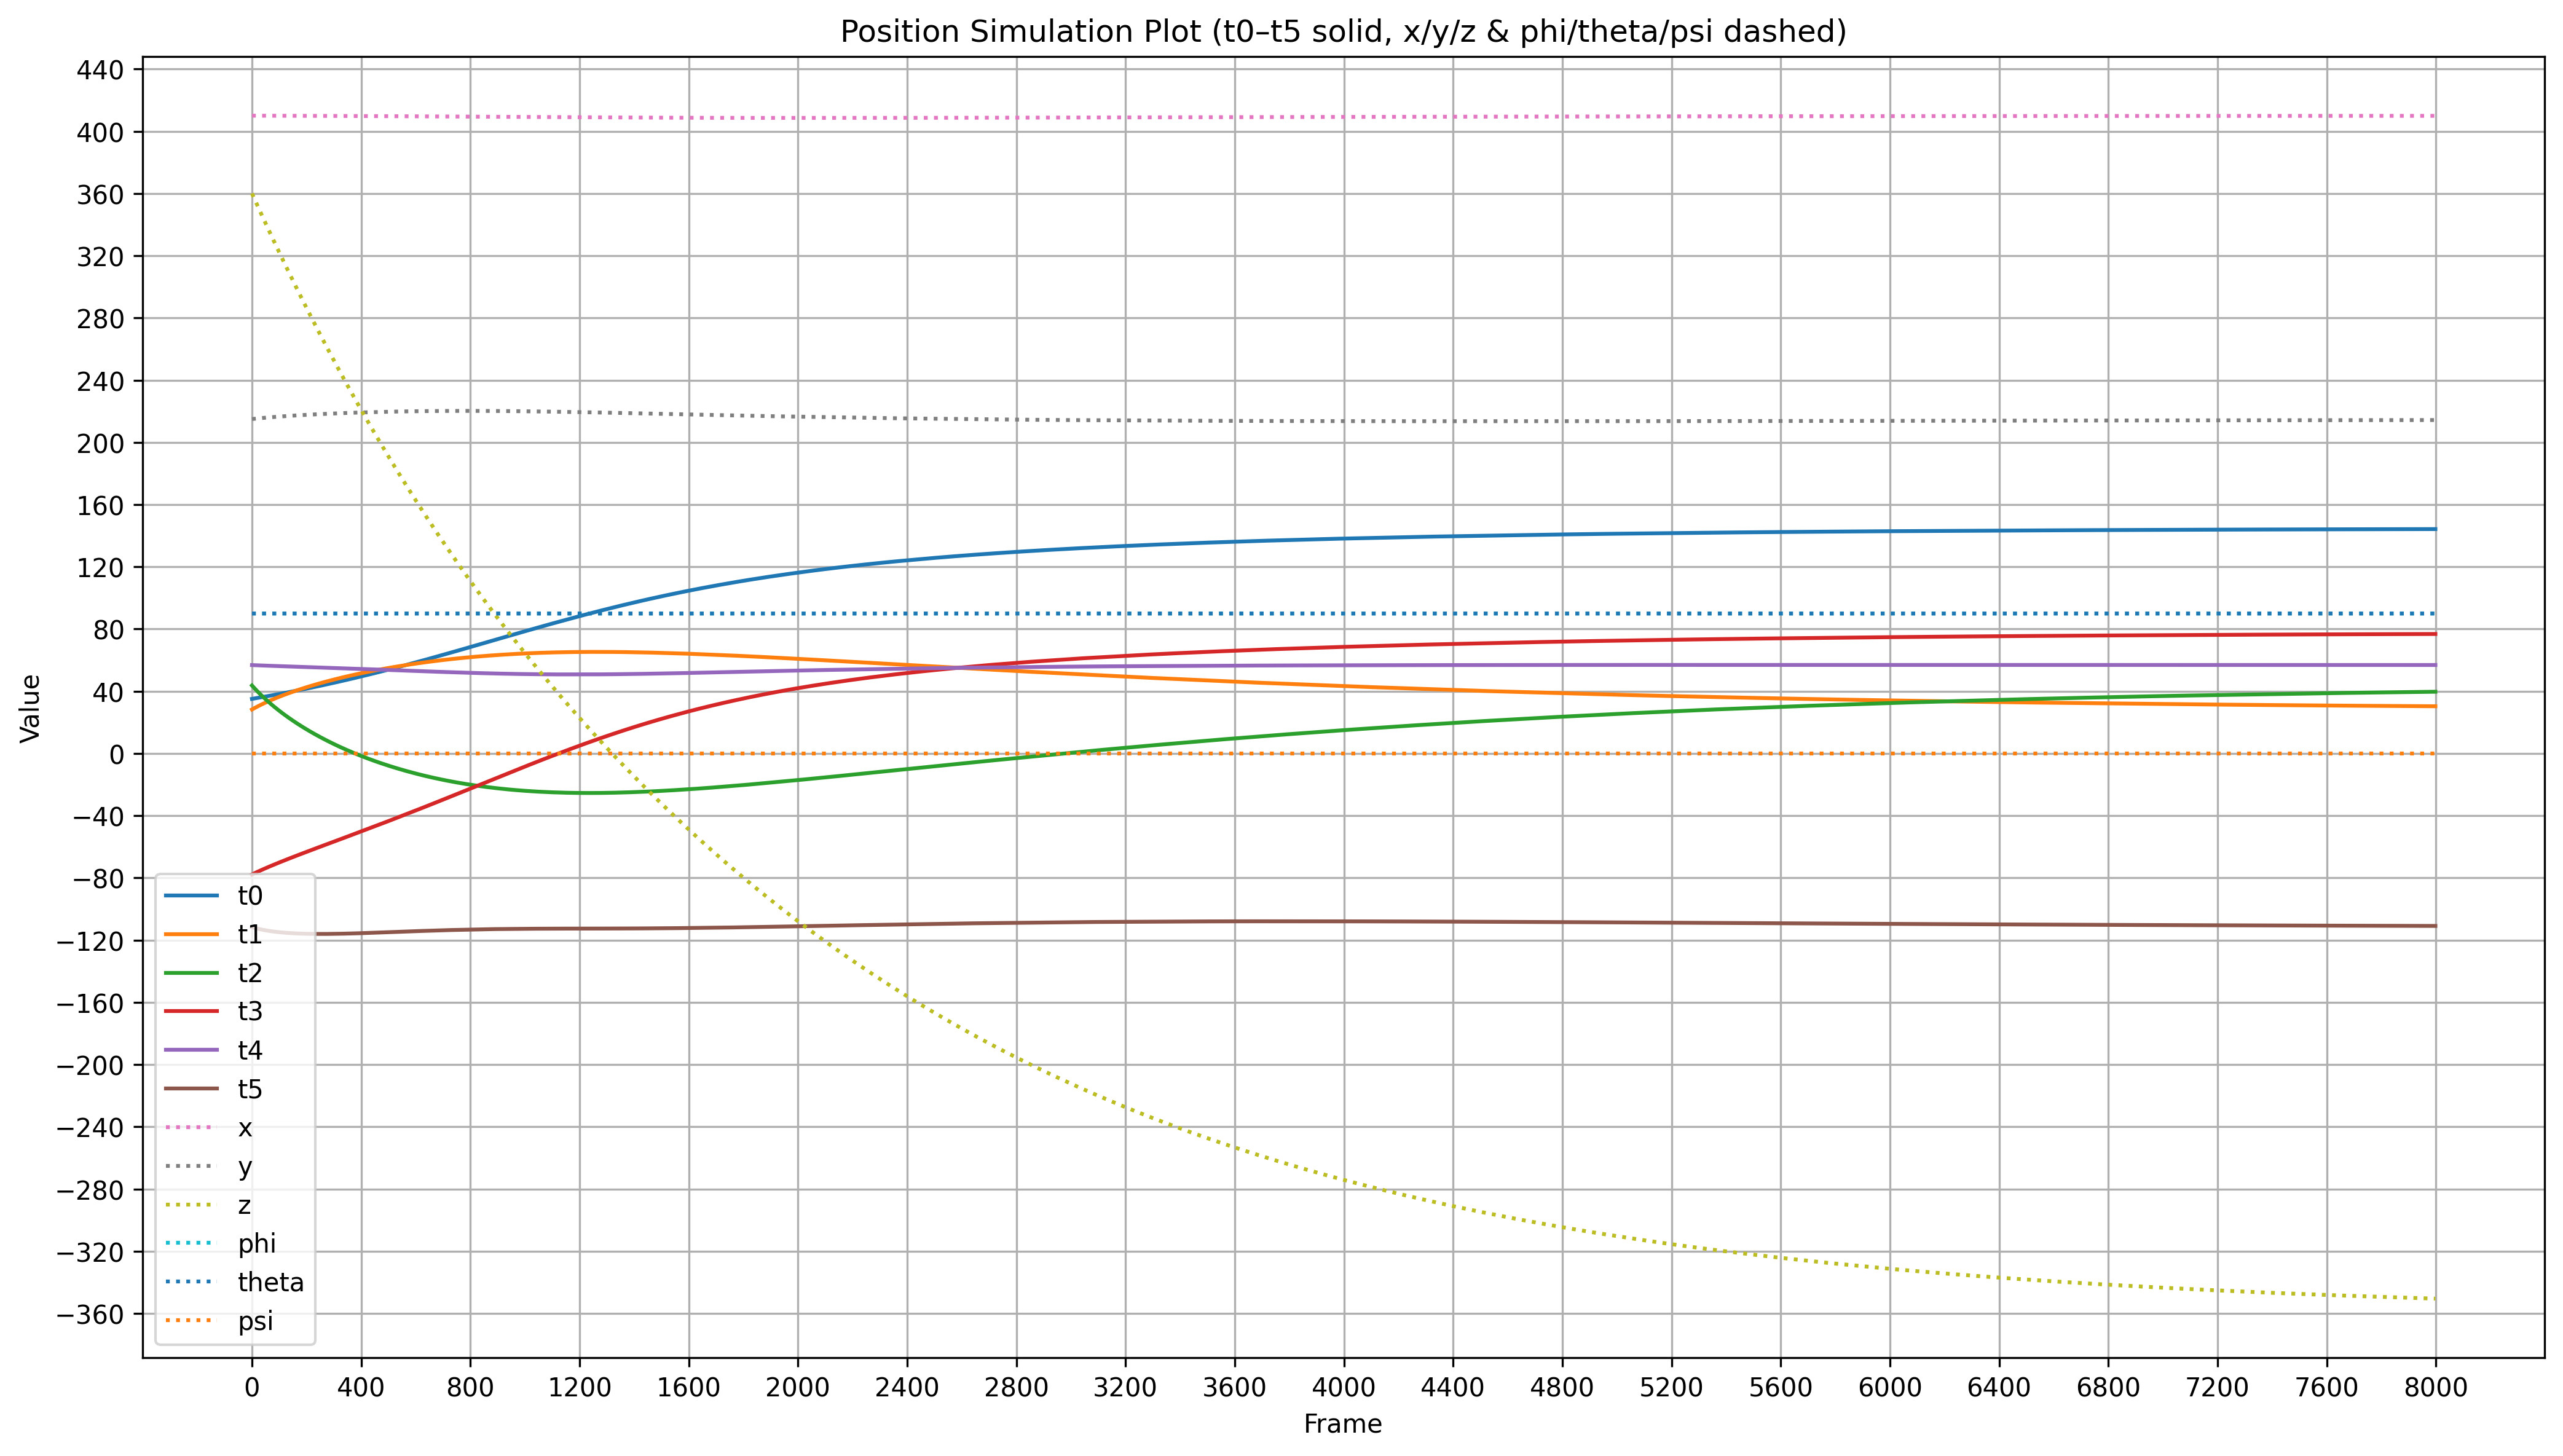

In [11]:
start_line = 0
end_line = None

plot_velocity("sim_vel3.log", start_line, end_line)
plot_pos("sim_pos3.log", start_line, end_line)

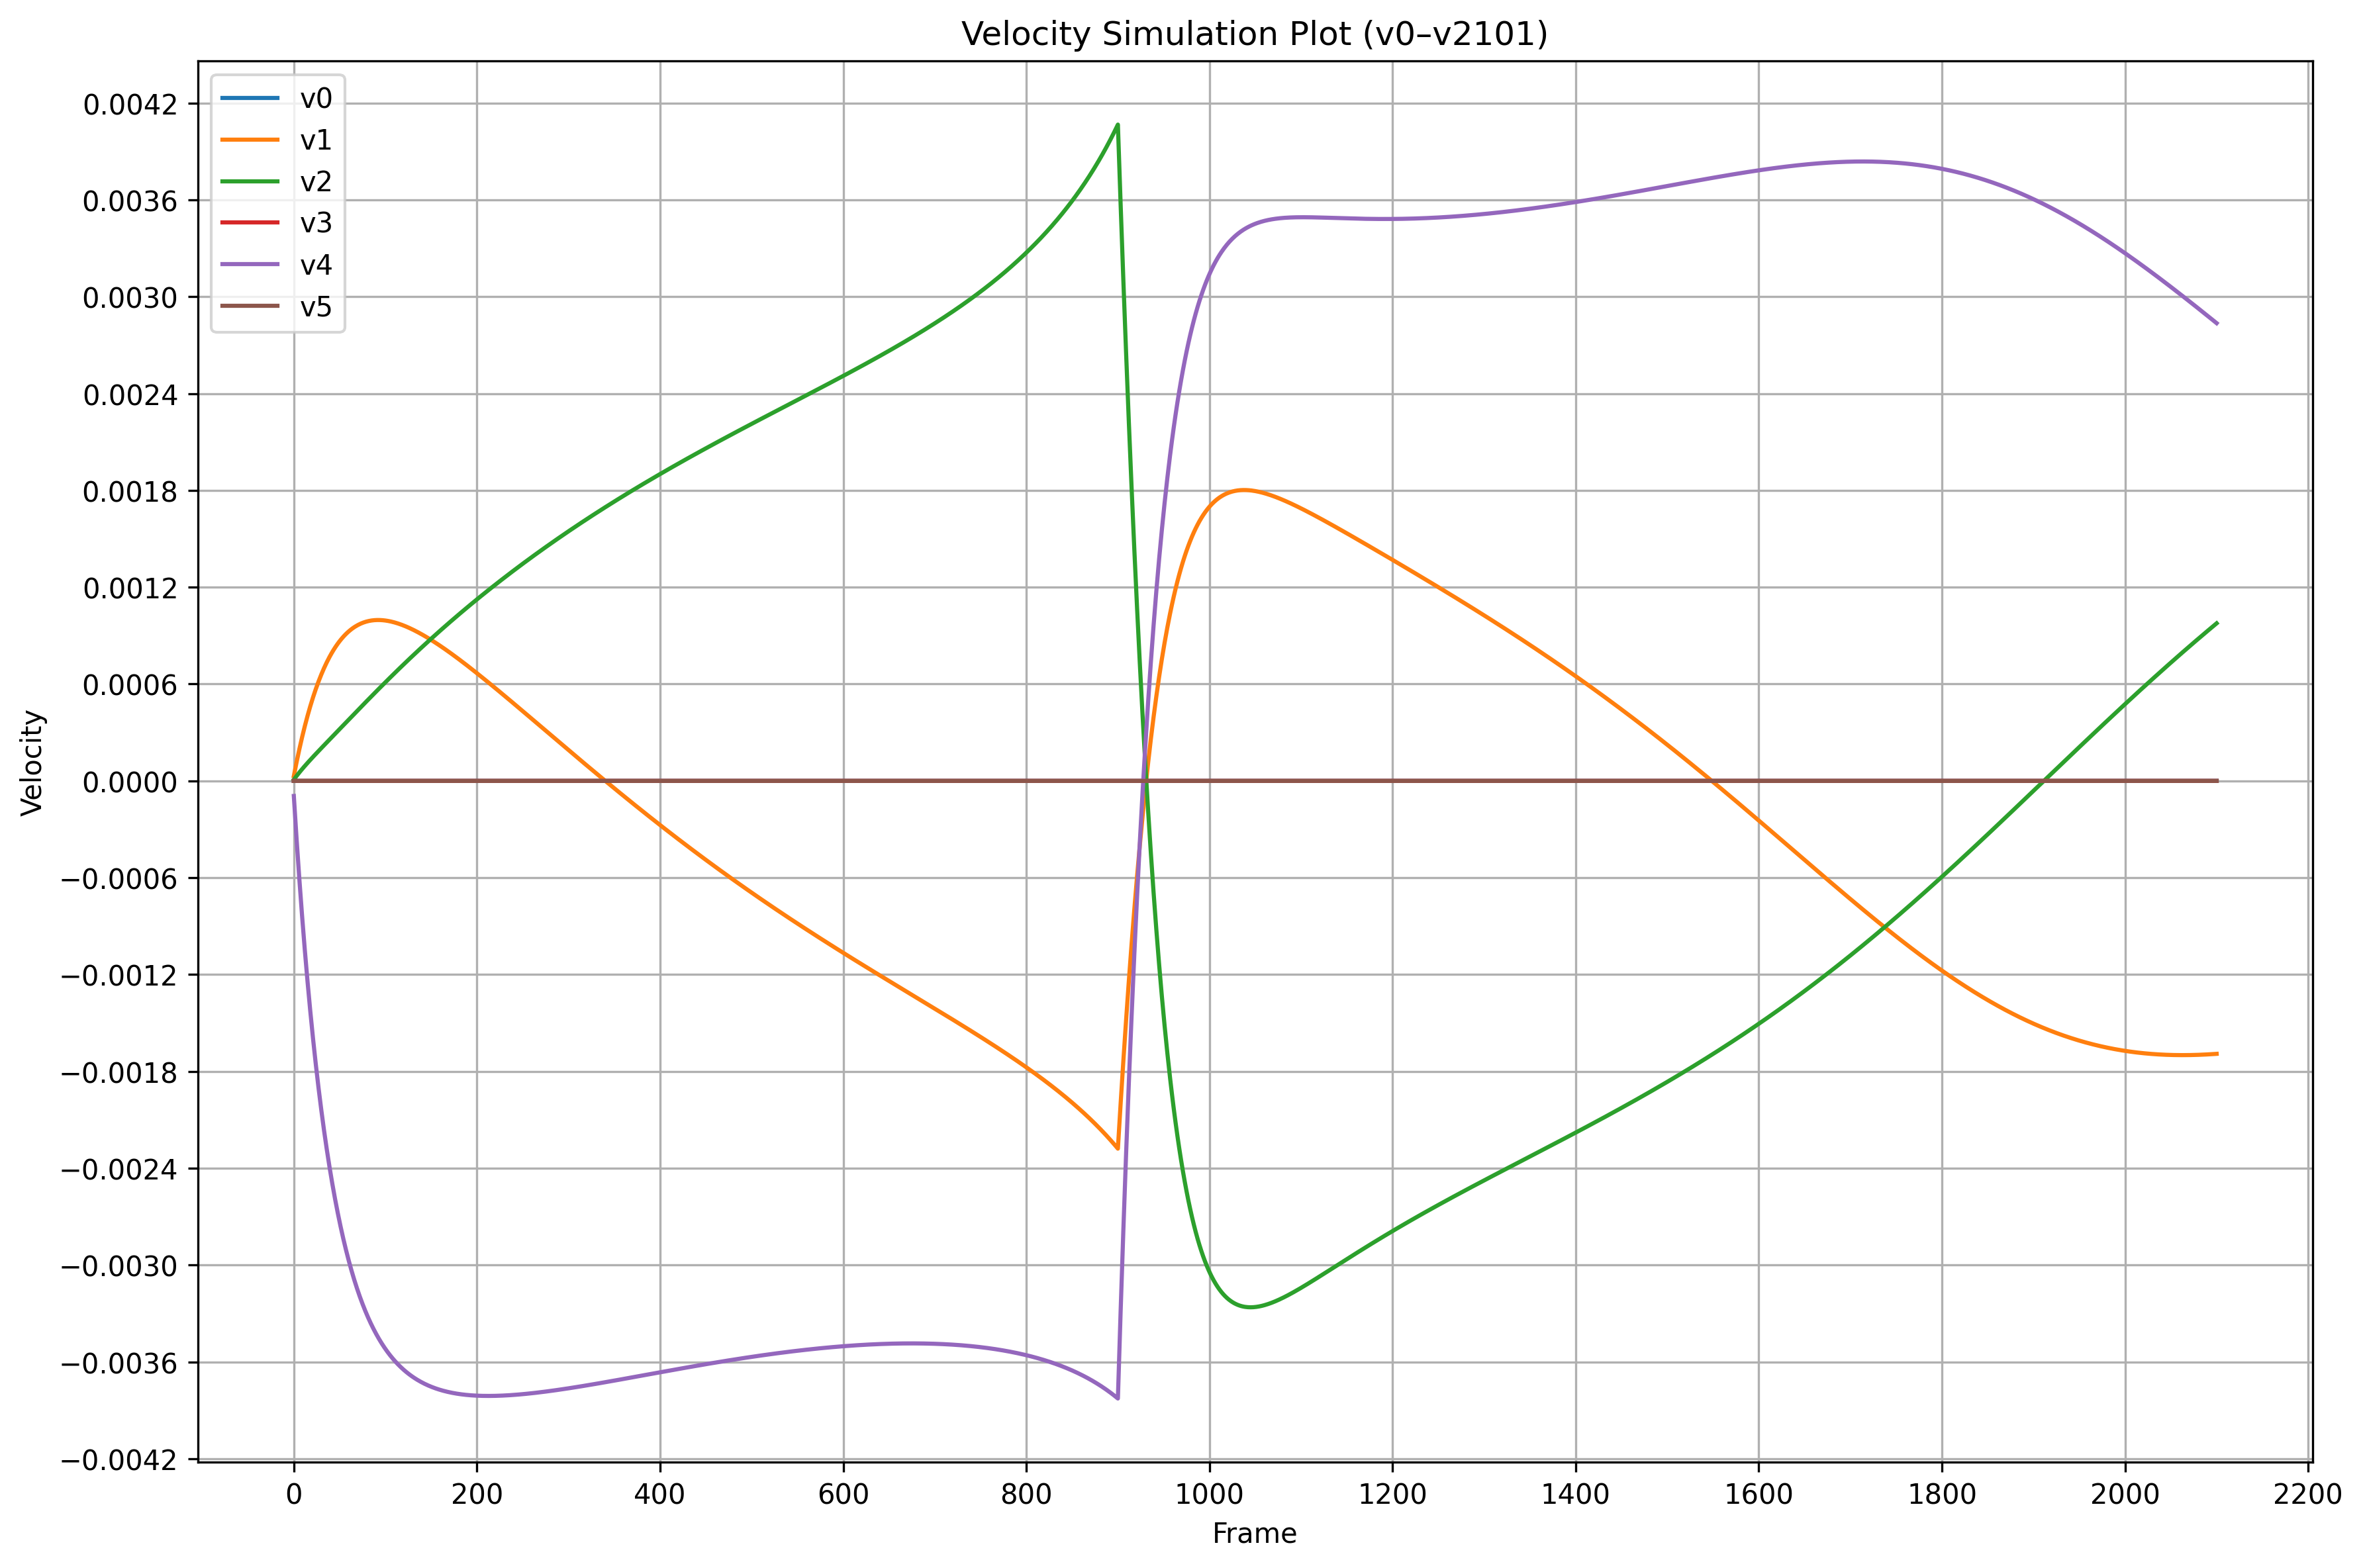

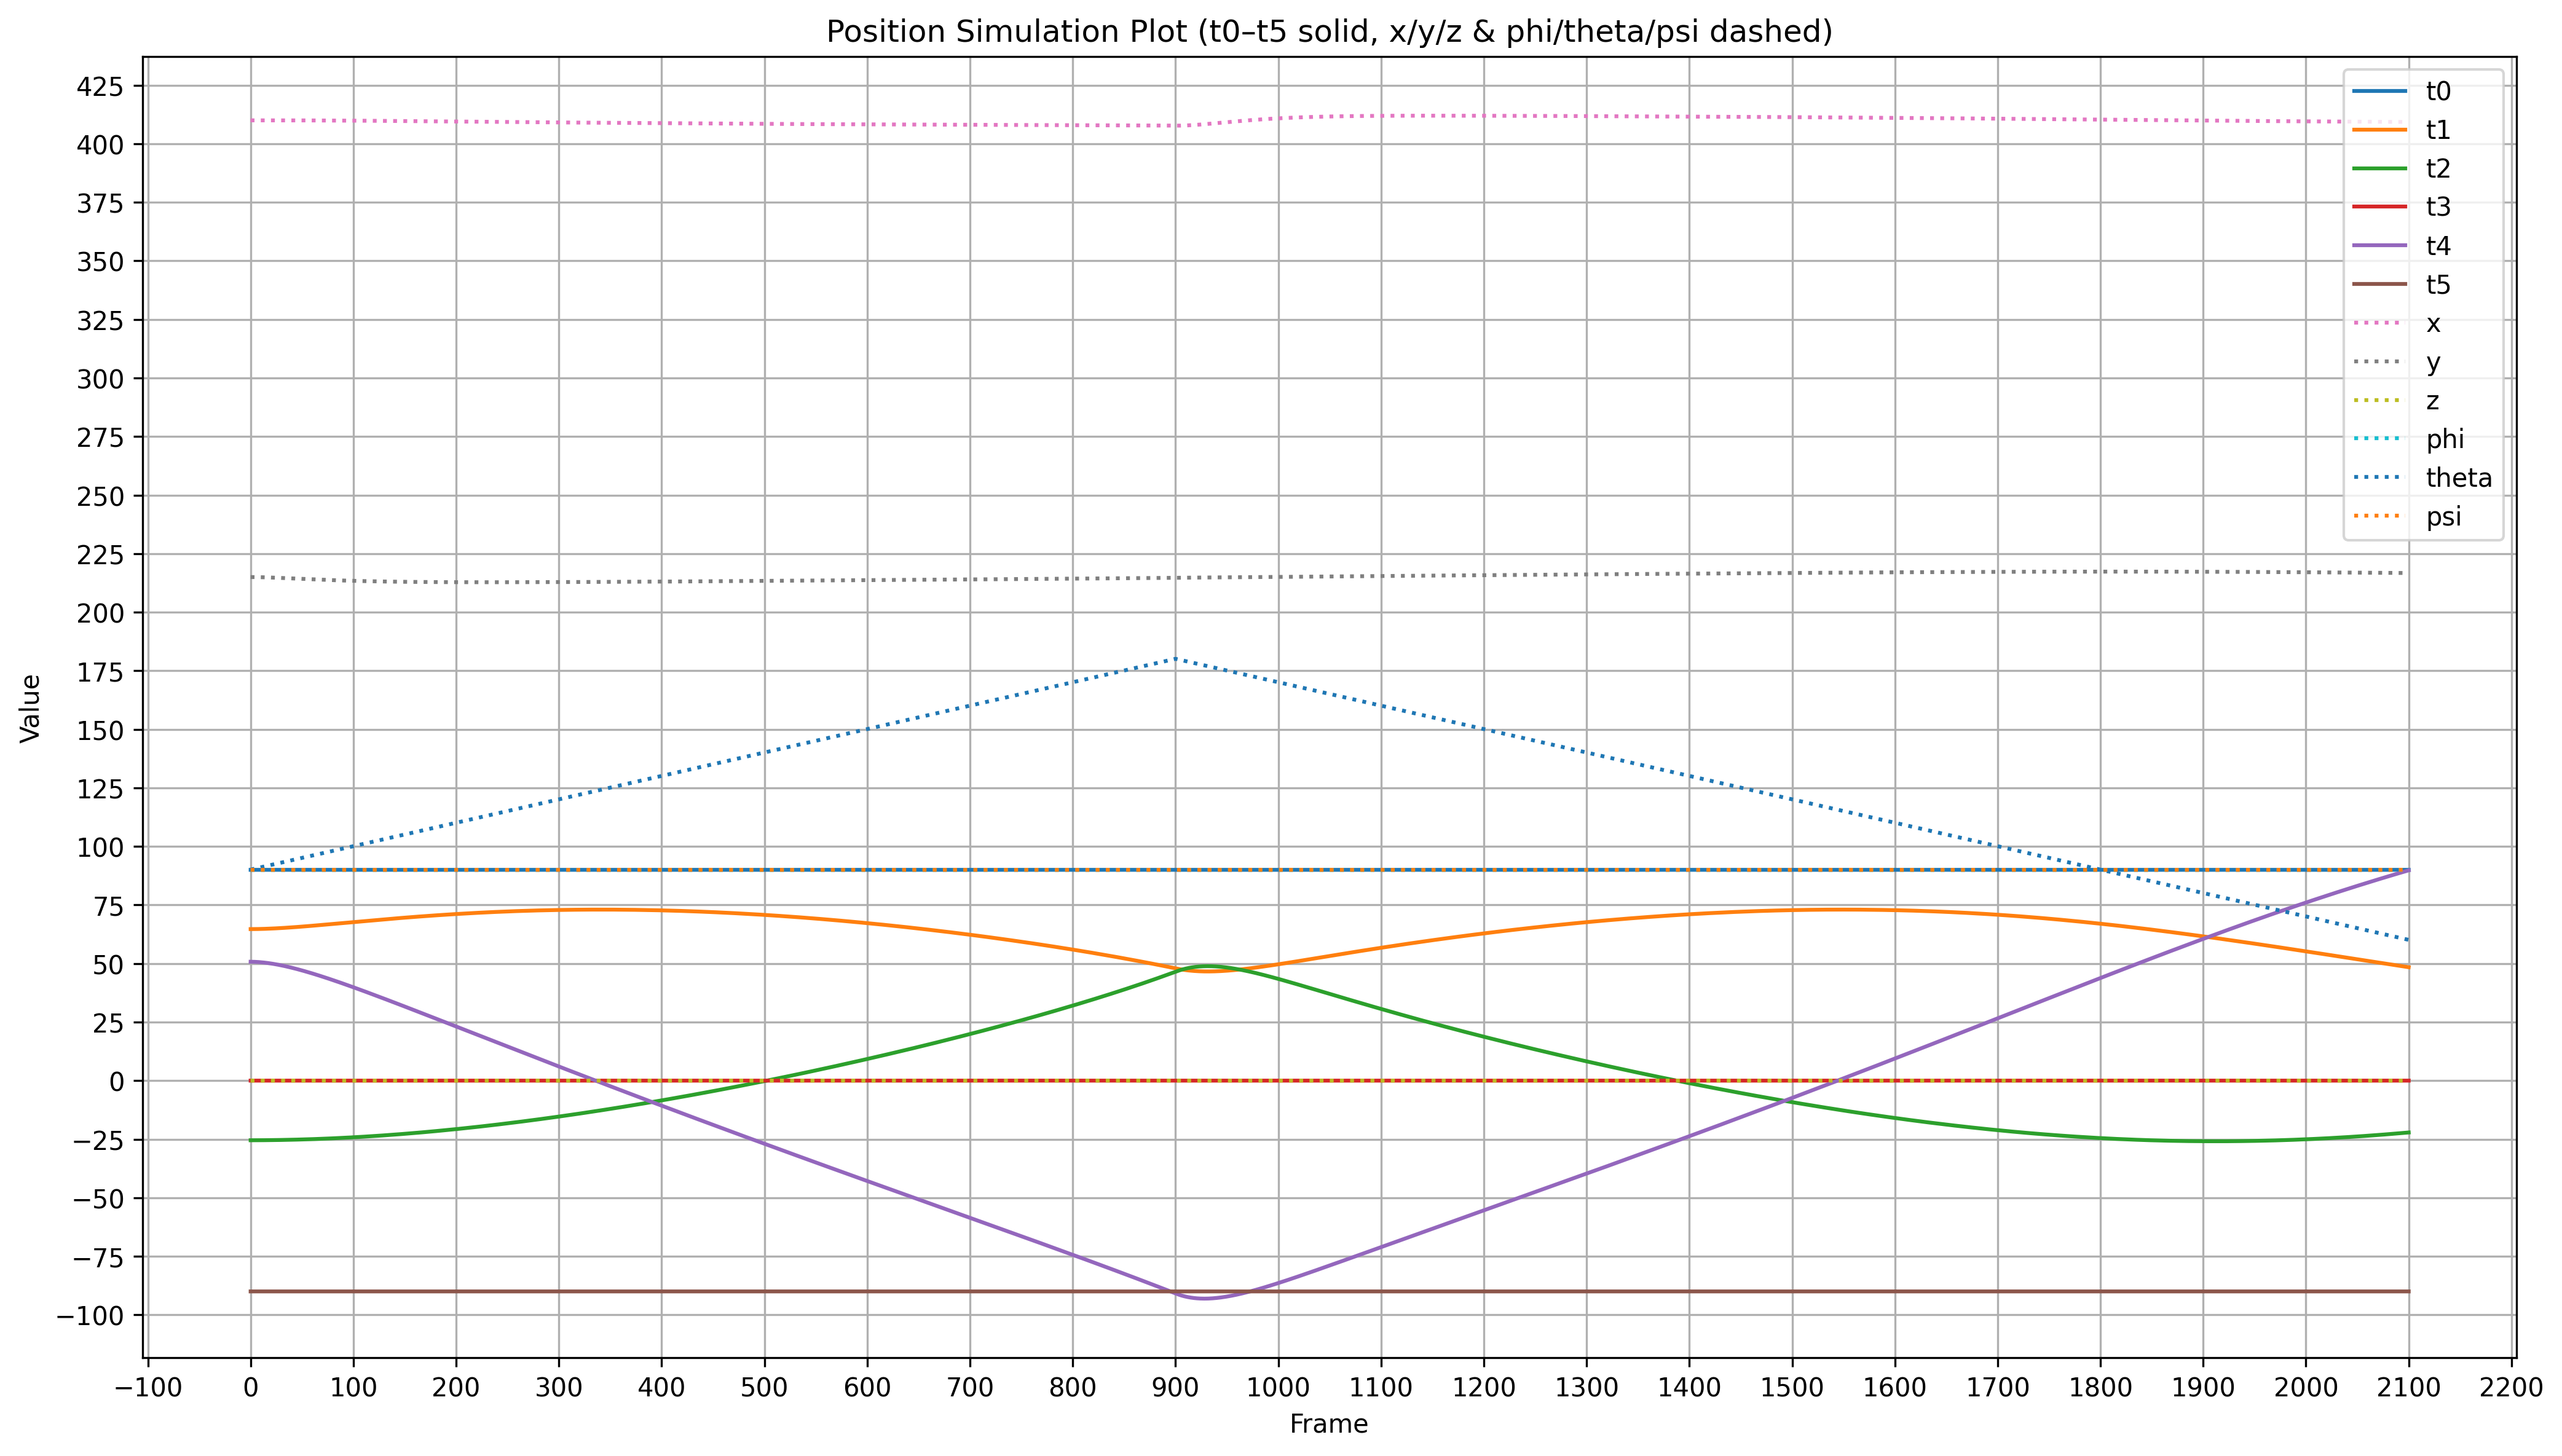

In [12]:
start_line = 0
end_line = 2100

plot_velocity("sim_vel4.log", start_line, end_line)
plot_pos("sim_pos4.log", start_line, end_line)